# Looking to build a volatility smile

In [147]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import scipy.stats as sci
from datetime import datetime
%matplotlib inline

In [148]:
# Black-Scholes equations for future use

def d1(S, K, T, r, sigma, q):
    return (np.log(S/K) + (r - q + (sigma **2 / 2)) * T) / (sigma * np.sqrt(T))

def d2(S, K, T, r, sigma, q):
    return d1(S, K, T, r, sigma, q) - sigma * np.sqrt(T)


def call_price(S, K, T, r, sigma, q):
    return sci.norm.cdf(d1(S, K, T, r, sigma, q))*S*np.exp(-q*T) - sci.norm.cdf(d2(S, K, T, r, sigma, q))*K*np.exp(-r*T)

In [149]:
ticker = yf.Ticker("SPY")
ticker_history = yf.download("SPY", start='2026-04-30', end=None)
S = ticker.fast_info['last_price']
expiry = datetime.strptime('2026-10-30', '%Y-%m-%d')
today = datetime.today()
T = (expiry - today).days / 365

tbill = yf.Ticker("^IRX")
r = tbill.fast_info['last_price'] / 100

q = 0.013

print(T)
print(S)
print(r)
print(ticker.options)
calls = ticker.option_chain('2026-10-30').calls
puts = ticker.option_chain('2026-10-30').puts

filtered_calls = calls[(calls['volume'] > 1) & (calls['openInterest'] > 50)]
filtered_puts = puts[(puts['volume'] > 1) & (puts['openInterest'] > 50)]

[*********************100%***********************]  1 of 1 completed


0.4712328767123288
737.6199951171875
0.0359500002861023
('2026-05-11', '2026-05-12', '2026-05-13', '2026-05-14', '2026-05-15', '2026-05-18', '2026-05-19', '2026-05-20', '2026-05-22', '2026-05-29', '2026-06-05', '2026-06-12', '2026-06-18', '2026-06-30', '2026-07-17', '2026-07-31', '2026-08-21', '2026-08-31', '2026-09-18', '2026-09-30', '2026-10-30', '2026-12-18', '2026-12-31', '2027-01-15', '2027-03-19', '2027-03-31', '2027-06-17', '2027-09-17', '2027-12-17', '2028-01-21', '2028-06-16', '2028-12-15')


In [150]:
print(filtered_calls, len(filtered_calls))

print(filtered_puts, len(filtered_puts))


print(filtered_calls['lastTradeDate'].dt.date)

        contractSymbol             lastTradeDate  strike  lastPrice    bid  \
31  SPY261030C00700000 2026-05-08 18:54:36+00:00   700.0      66.44  65.04   
37  SPY261030C00710000 2026-05-08 19:13:54+00:00   710.0      58.89  57.88   
42  SPY261030C00715000 2026-05-08 17:13:37+00:00   715.0      55.36  53.75   
47  SPY261030C00720000 2026-05-08 19:07:24+00:00   720.0      51.59  51.21   
52  SPY261030C00725000 2026-05-08 18:29:37+00:00   725.0      48.18  46.92   
53  SPY261030C00726000 2026-05-06 17:09:30+00:00   726.0      43.68  46.24   
54  SPY261030C00727000 2026-05-07 14:11:30+00:00   727.0      45.07  45.19   
55  SPY261030C00728000 2026-05-06 16:41:52+00:00   728.0      42.56  44.51   
57  SPY261030C00730000 2026-05-08 19:13:54+00:00   730.0      44.71  43.69   
58  SPY261030C00731000 2026-05-07 19:59:18+00:00   731.0      42.29  42.47   
59  SPY261030C00732000 2026-05-08 16:21:29+00:00   732.0      43.68  41.93   
62  SPY261030C00735000 2026-05-08 19:44:05+00:00   735.0      41

In [151]:
ticker_history.columns = ticker_history.columns.droplevel(1)
ticker_history['date'] = ticker_history.index.date
filtered_calls['date'] = filtered_calls['lastTradeDate'].dt.date
filtered_calls = filtered_calls.merge(ticker_history[['date', 'Close']], on='date')

call_prices = call_price(filtered_calls['Close'], filtered_calls['strike'], T, r, filtered_calls['impliedVolatility'], q)
difference = call_prices - (filtered_calls['bid'].values.flatten() + filtered_calls['ask'].values.flatten())/2

/tmp/ipykernel_73608/235001728.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_calls['date'] = filtered_calls['lastTradeDate'].dt.date


In [152]:
print(np.mean(difference))

3.0376907501650217


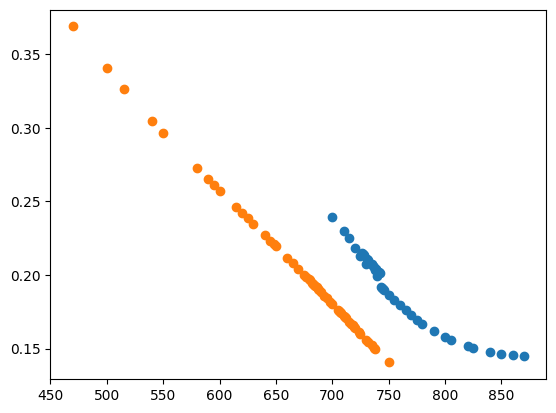

In [154]:
plt.scatter(filtered_calls['strike'], filtered_calls['impliedVolatility'])
plt.scatter(filtered_puts['strike'], filtered_puts['impliedVolatility'])
plt.show()